
================ DATA OVERVIEW ================
Shape: (15000, 21)

Columns: ['job_id', 'job_title', 'salary_usd', 'salary_currency', 'experience_level', 'employment_type', 'company_location', 'company_size', 'employee_residence', 'remote_ratio', 'required_skills', 'education_required', 'years_experience', 'industry', 'posting_date', 'application_deadline', 'job_description_length', 'benefits_score', 'company_name', 'year', 'ai_period']

Missing values:
 job_id                    0
job_title                 0
salary_usd                0
salary_currency           0
experience_level          0
employment_type           0
company_location          0
company_size              0
employee_residence        0
remote_ratio              0
required_skills           0
education_required        0
years_experience          0
industry                  0
posting_date              0
application_deadline      0
job_description_length    0
benefits_score            0
company_name              0
year    

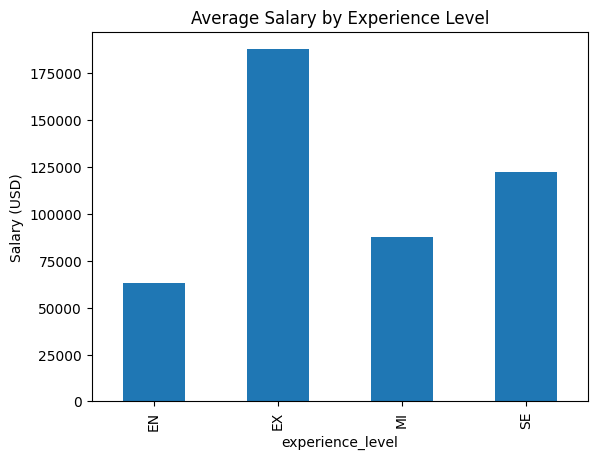

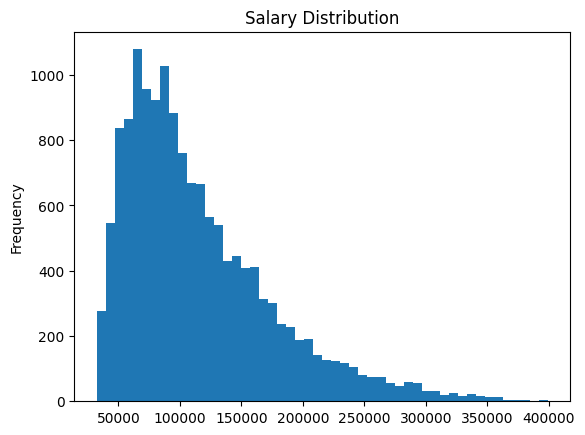

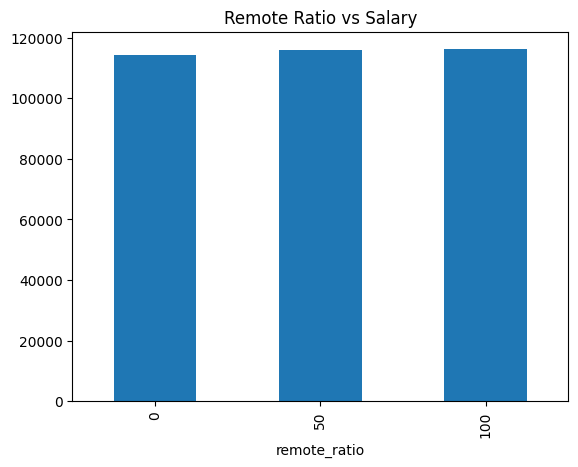

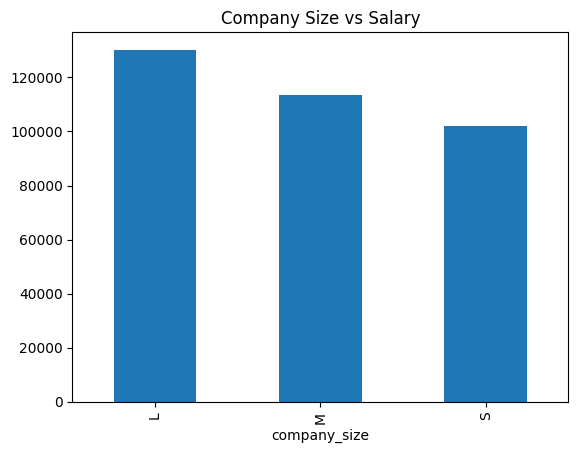

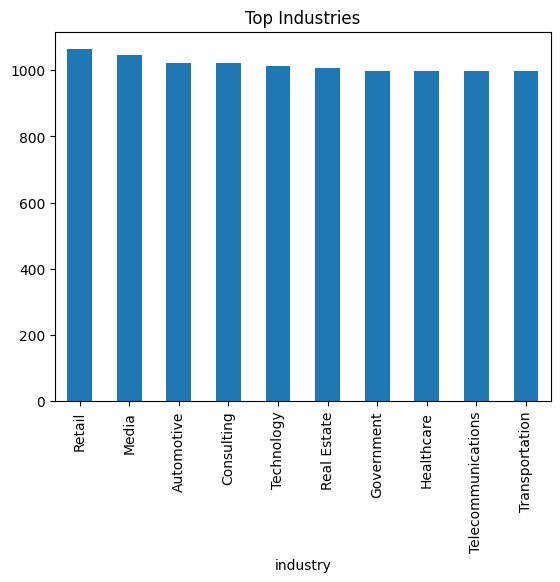

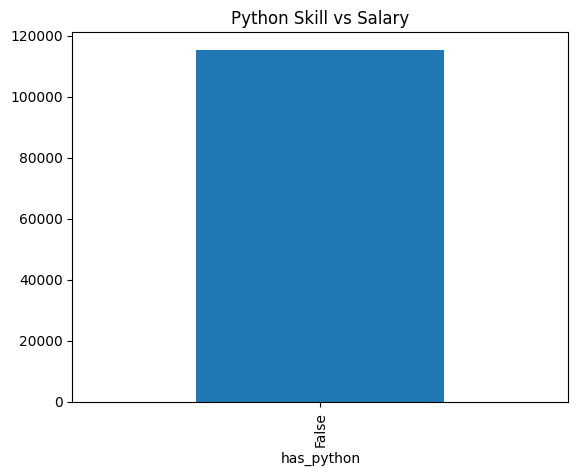

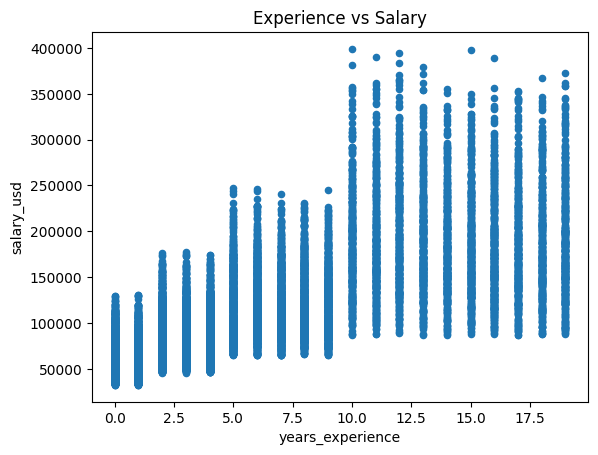

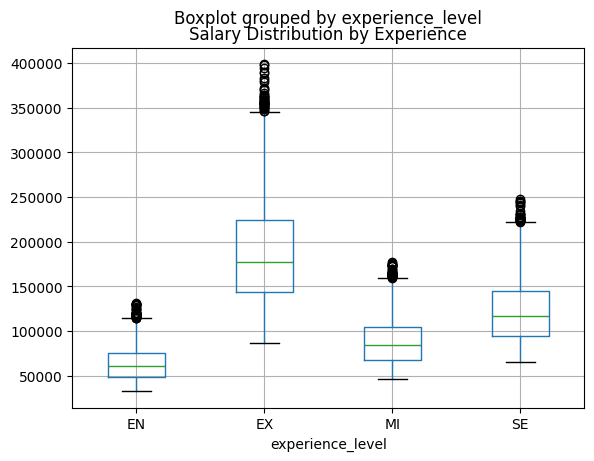

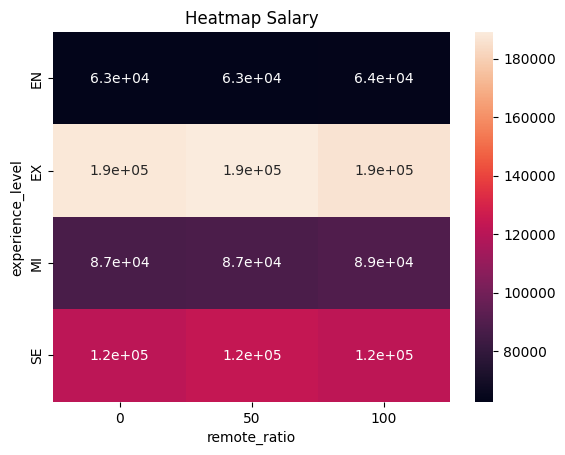

In [7]:
import pandas as pd
from collections import Counter
import seaborn as sns
import matplotlib.pyplot as plt

def analyze():
    df = pd.read_csv("../data/processed/jobs_cleaned.csv")

    print("\n================ DATA OVERVIEW ================")
    print("Shape:", df.shape)
    print("\nColumns:", df.columns.tolist())
    print("\nMissing values:\n", df.isnull().sum())

    # =====================================================
    print("\n================ SALARY ANALYSIS ================")
    print(df['salary_usd'].describe())
    
    print("\nSalary by Experience Level:")
    print(df.groupby('experience_level')['salary_usd'].mean())

    print("\nSalary by Years of Experience:")
    print(df.groupby('years_experience')['salary_usd'].mean().head(10))

    print("\nSalary per Year of Experience:")
    df['salary_per_year_exp'] = df['salary_usd'] / (df['years_experience'] + 1)
    print(df['salary_per_year_exp'].describe())

    # =====================================================
    print("\n================ INDUSTRY ANALYSIS ================")
    print(df['industry'].value_counts().head(10))

    print("\nTop Paying Industries:")
    print(df.groupby('industry')['salary_usd'].mean().sort_values(ascending=False).head(10))

    print("\nIndustry + Experience:")
    print(df.groupby(['industry', 'experience_level'])['salary_usd'].mean())

    # =====================================================
    print("\n================ REMOTE WORK ANALYSIS ================")
    print(df.groupby('remote_ratio')['salary_usd'].mean())

    print("\nRemote + Experience:")
    print(df.groupby(['remote_ratio', 'experience_level'])['salary_usd'].mean())

    # =====================================================
    print("\n================ COMPANY ANALYSIS ================")
    print("\nCompany Size vs Salary:")
    print(df.groupby('company_size')['salary_usd'].mean())

    print("\nTop Paying Locations:")
    print(df.groupby('company_location')['salary_usd'].mean().sort_values(ascending=False).head(10))

    # =====================================================
    print("\n================ EDUCATION ANALYSIS ================")
    print(df.groupby('education_required')['salary_usd'].mean())

    # =====================================================
    print("\n================ EMPLOYMENT TYPE ================")
    print(df.groupby('employment_type')['salary_usd'].mean())

    # =====================================================
    print("\n================ BENEFITS ANALYSIS ================")
    print(df.groupby('benefits_score')['salary_usd'].mean())

    # =====================================================
    print("\n================ JOB DESCRIPTION ANALYSIS ================")
    print(df.groupby(pd.cut(df['job_description_length'], bins=5))['salary_usd'].mean())

    # =====================================================
    print("\n================ SKILL ANALYSIS ================")

    skills_series = df['required_skills'].dropna().str.lower().str.split(',')
    all_skills = [s.strip() for sub in skills_series for s in sub]

    skill_counts = Counter(all_skills)
    print("\nTop 15 Skills:")
    print(skill_counts.most_common(15))

    # Skill count
    df['skill_count'] = df['required_skills'].str.split(',').apply(len)
    print("\nSkill Count vs Salary:")
    print(df.groupby('skill_count')['salary_usd'].mean().head(10))

    # AI / Python detection
    df['has_python'] = df['required_skills'].str.contains('python', na=False)
    df['has_ai'] = df['required_skills'].str.contains('ai|machine learning', na=False)

    print("\nPython vs Salary:")
    print(df.groupby('has_python')['salary_usd'].mean())

    print("\nAI Skill vs Salary:")
    print(df.groupby('has_ai')['salary_usd'].mean())

    # =====================================================
    print("\n================ TIME ANALYSIS ================")
    print(df.groupby('year').size())
    print("\n⚠️ Note: 2025 may be incomplete")

    # =====================================================
    print("\n================ ADVANCED METRICS ================")

    # Salary efficiency
    df['salary_efficiency'] = df['salary_usd'] / (df['years_experience'] + 1)
    print("\nSalary Efficiency:")
    print(df['salary_efficiency'].describe())

    # Cross feature insight
    print("\nExperience + Remote + Salary:")
    print(df.groupby(['experience_level', 'remote_ratio'])['salary_usd'].mean())

    print("\nEducation + Industry:")
    print(df.groupby(['education_required', 'industry']).size())

    print("\n===============================================")
    print("🔥 FULL ANALYSIS COMPLETED 🔥")



    df.groupby('experience_level')['salary_usd'].mean().plot(kind='bar')
    plt.title("Average Salary by Experience Level")
    plt.ylabel("Salary (USD)")
    plt.show()

    df['salary_usd'].plot(kind='hist', bins=50)
    plt.title("Salary Distribution")
    plt.show()

    df.groupby('remote_ratio')['salary_usd'].mean().plot(kind='bar')
    plt.title("Remote Ratio vs Salary")
    plt.show()

    df.groupby('company_size')['salary_usd'].mean().plot(kind='bar')
    plt.title("Company Size vs Salary")
    plt.show()

    df['industry'].value_counts().head(10).plot(kind='bar')
    plt.title("Top Industries")
    plt.show()

    df['has_python'] = df['required_skills'].str.contains('python', na=False)
    df.groupby('has_python')['salary_usd'].mean().plot(kind='bar')
    plt.title("Python Skill vs Salary")
    plt.show()


    df.plot.scatter(x='years_experience', y='salary_usd')
    plt.title("Experience vs Salary")
    plt.show()


    df.boxplot(column='salary_usd', by='experience_level')
    plt.title("Salary Distribution by Experience")
    plt.show()

    pivot = df.pivot_table(values='salary_usd', index='experience_level', columns='remote_ratio')
    sns.heatmap(pivot, annot=True)
    plt.title("Heatmap Salary")
    plt.show()

analyze()






